### This script entitled to output the box plot of the pattern correlation of the simulation and observations, overlapped with the MMEM, SMILE ensemble pattern versus observations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import xarray as xr
import pandas as pd
import os
import sys
import warnings
warnings.filterwarnings("ignore")

In [2]:
# def read_correlations(file_path):
#     with open(file_path, 'r') as file:
#         # Split the file content by newlines and convert each piece to a float
#         return [float(correlation) for correlation in file.read().splitlines()]

In [3]:
# In[2]:
# input pattern correlation from NetCDF files:
def read_correlations(file_path):
    """
    Read pattern correlation data from a NetCDF file with variables:
      - pattern_corr_run_vs_mmem(run, period)
      - pattern_corr_obs_vs_mmem(period)

    Returns
    -------
    run_correlations : dict
        { '2013-2022': [list of run correlations across all runs in this model],
          '1993-2022': [...],
          '1963-2022': [...],
          '1979-2022': [...] }

    obs_correlations : dict
        Same keys, but each entry is a list of obs-vs-MMEM values
        (usually length 1 per model per period).
    """
    import xarray as xr
    import numpy as np

    target_periods = ['2013-2022', '1993-2022', '1963-2022', '1979-2022']

    run_correlations = {k: [] for k in target_periods}
    obs_correlations = {k: [] for k in target_periods}

    ds = xr.open_dataset(file_path)

    periods = ds['period'].values.astype(str)
    run_vs_mmem = ds['pattern_corr_run_vs_mmem'].values   # (run, period)
    obs_vs_mmem = ds['pattern_corr_obs_vs_mmem'].values   # (period,)

    for idx, period_str in enumerate(periods):
        period_str = period_str.strip()
        # period_str should be like "1950-2022", "2013-2022", etc.
        try:
            start_str, end_str = period_str.split('-')
        except ValueError:
            # unexpected format, skip
            continue

        label = f"{start_str}-{end_str}"
        if label not in run_correlations:
            continue  # we only care about the four chosen windows

        # collect all runs for this period
        vals = run_vs_mmem[:, idx]
        run_correlations[label].extend([float(v) for v in vals if np.isfinite(v)])

        # obs vs MMEM (single value for this period)
        obs_val = float(obs_vs_mmem[idx])
        if np.isfinite(obs_val):
            obs_correlations[label].append(obs_val)

    ds.close()
    return run_correlations, obs_correlations


In [22]:
def read_correlations_text(file_path):
    correlations = {
        '10-year': [],
        '30-year': [],
        '44-year': [],
        '60-year': []
    }
    
    current_period = None

    with open(file_path, 'r') as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            
            # Check if this is a header line
            if 'Trend Pattern Correlations' in line:
                if '10-year' in line:
                    current_period = '10-year'
                elif '30-year' in line:
                    current_period = '30-year'
                elif '44-year' in line:
                    current_period = '44-year'
                elif '60-year' in line:
                    current_period = '60-year'
            else:
                # Try to parse data lines
                if current_period and ':' in line:
                    try:
                        # Format: "MODEL: value"
                        parts = line.split(':')
                        value = float(parts[1].strip())
                        correlations[current_period].append(value)
                    except (ValueError, IndexError):
                        pass

    return correlations

In [23]:
# In[3]: paths & models
dir_in = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG3/Pattern_correlation_pearson/'
MODELS = ['CanESM5', 'CESM2', 'IPSL_CM6A', 'EC_Earth3', 'ACCESS', 'MPI_ESM', 'MIROC6']

# pretty labels for plotting
MODEL_LABELS = {
    'CanESM5':        'CanESM5',
    'CESM2':          'CESM2',
    'IPSL_CM6A':      'IPSL-CM6A-LR',
    'EC_Earth3':      'EC-Earth3',
    'ACCESS':         'ACCESS-ESM1.5',
    'MPI_ESM':        'MPI-ESM1.2-LR',
    'MIROC6':         'MIROC6',
}

# ------------------------------------------------------------------
# 1) Read FORCED pattern correlations (run vs MMEM, obs vs MMEM)
#    from: <model>/<model>_pattern_correlation_run_and_obs_vs_MMEM_1950-2022_sliding.nc
# ------------------------------------------------------------------
forced_run_corr   = {}  # model -> dict(period -> list of run correlations)
forced_obs_corr   = {}  # model -> dict(period -> list of obs correlations)
for m in MODELS:
    nc_path = os.path.join(
        dir_in,
        m,
        f"{m}_forced_pattern_correlation_run_and_obs_vs_MMEM_1950-2022_sliding.nc",
    )
    run_corr, obs_corr = read_correlations(nc_path)
    forced_run_corr[m] = run_corr
    forced_obs_corr[m] = obs_corr

# ------------------------------------------------------------------
# 2) Read UNFORCED (ICV std) pattern correlations
#    from: <model>/<model>_ICVstd_pattern_correlation_run_and_obs_vs_MMEM_1950-2022_sliding.nc
# ------------------------------------------------------------------
unforced_run_corr = {}
unforced_obs_corr = {}
for m in MODELS:
    nc_path = os.path.join(
        dir_in,
        m,
        f"{m}_ICVstd_pattern_correlation_run_and_obs_vs_MMEM_1950-2022_sliding.nc",
    )
    run_corr, obs_corr = read_correlations(nc_path)
    unforced_run_corr[m] = run_corr
    unforced_obs_corr[m] = obs_corr

In [6]:
forced_run_corr

{'CanESM5': {'2013-2022': [0.8432131560302136,
   0.855784866717434,
   0.8483361780868608,
   0.8184523544932947,
   0.9060731616607991,
   0.9160149417646614,
   0.7740073709070348,
   0.6610737828127391,
   0.9108030850549739,
   0.9212646569419264,
   0.8640321685690635,
   0.8929950690481674,
   0.8707430551424653,
   0.8667344188684782,
   0.8549883215758266,
   0.7953330140528075,
   0.8649634096381784,
   0.8992253704781001,
   0.9228759631075235,
   0.8512657372216882,
   0.9101068300612543,
   0.8700780990516948,
   0.8694563851760095,
   0.8754281229985362,
   0.8631882970486702,
   0.9069315260462315,
   0.8942427139712817,
   0.8591966115570604,
   0.8832376968842505,
   0.771041765139262,
   0.8735852412228249,
   0.8126662644086698,
   0.8752177355950613,
   0.8572867397638758,
   0.8590850658056252,
   0.8831367635974278,
   0.8917820560467279,
   0.8622483458621807,
   0.8446728280348316,
   0.860552744710003,
   0.7948205063828577,
   0.8381293666181879,
   0.84894715

In [7]:
forced_obs_corr

{'CanESM5': {'2013-2022': [0.7169836716588345],
  '1993-2022': [0.7828991617815826],
  '1963-2022': [0.7827507138202511],
  '1979-2022': [0.7874805232455475]},
 'CESM2': {'2013-2022': [-0.31232755307261806],
  '1993-2022': [0.7288305079537036],
  '1963-2022': [0.7765655854662259],
  '1979-2022': [0.7772711516366302]},
 'IPSL_CM6A': {'2013-2022': [0.726255051464672],
  '1993-2022': [0.7566114110101381],
  '1963-2022': [0.8406127117621573],
  '1979-2022': [0.8085866070835774]},
 'EC_Earth3': {'2013-2022': [0.5340499480716099],
  '1993-2022': [0.8112759196573832],
  '1963-2022': [0.819284634385369],
  '1979-2022': [0.8189757268148571]},
 'ACCESS': {'2013-2022': [0.78952217738241],
  '1993-2022': [0.8039624281120964],
  '1963-2022': [0.858473942757094],
  '1979-2022': [0.8465185583241243]},
 'MPI_ESM': {'2013-2022': [0.6269902340358183],
  '1993-2022': [0.8553397372359123],
  '1963-2022': [0.8445952390128938],
  '1979-2022': [0.8508680524304557]},
 'MIROC6': {'2013-2022': [0.69621548075983

In [8]:
# Input the MMEM pattern correlation (forced)
ens_obs_corr = read_correlations_text('/work/mh0033/m301036/OBS_LPS_revision/script/Supp_Figures/FIGS7_S8/pattern_correlations_ENS_Obs_Forced.txt')

# Create models_data from forced correlations with proper mapping
models_data = {}
for model in MODELS:
    model_label = MODEL_LABELS[model]
    models_data[model_label] = {
        '10-year': forced_run_corr[model]['2013-2022'],
        '30-year': forced_run_corr[model]['1993-2022'],
        '60-year': forced_run_corr[model]['1963-2022']
    }

# Create models_unforced_data from unforced correlations
models_unforced_data = {}
for model in MODELS:
    model_label = MODEL_LABELS[model]
    models_unforced_data[model_label] = {
        '10-year': unforced_run_corr[model]['2013-2022'],
        '30-year': unforced_run_corr[model]['1993-2022'],
        '60-year': unforced_run_corr[model]['1963-2022']
    }

In [9]:
models_data

{'CanESM5': {'10-year': [0.8432131560302136,
   0.855784866717434,
   0.8483361780868608,
   0.8184523544932947,
   0.9060731616607991,
   0.9160149417646614,
   0.7740073709070348,
   0.6610737828127391,
   0.9108030850549739,
   0.9212646569419264,
   0.8640321685690635,
   0.8929950690481674,
   0.8707430551424653,
   0.8667344188684782,
   0.8549883215758266,
   0.7953330140528075,
   0.8649634096381784,
   0.8992253704781001,
   0.9228759631075235,
   0.8512657372216882,
   0.9101068300612543,
   0.8700780990516948,
   0.8694563851760095,
   0.8754281229985362,
   0.8631882970486702,
   0.9069315260462315,
   0.8942427139712817,
   0.8591966115570604,
   0.8832376968842505,
   0.771041765139262,
   0.8735852412228249,
   0.8126662644086698,
   0.8752177355950613,
   0.8572867397638758,
   0.8590850658056252,
   0.8831367635974278,
   0.8917820560467279,
   0.8622483458621807,
   0.8446728280348316,
   0.860552744710003,
   0.7948205063828577,
   0.8381293666181879,
   0.8489471502

In [ ]:
# Merge ensemble observation correlations with MMEM values
merged_data = {}
for key in ens_obs_corr.keys():
    merged_data[key] = ens_obs_corr[key][1:]
    merged_data[key].append(ens_obs_corr[key][0])  # Use first value as MMEM

In [13]:
ensemble_data ={
    'CanESM5': {'10-year': forced_obs_corr['CanESM5']['2013-2022'], '30-year': forced_obs_corr['CanESM5']['1993-2022'], '60-year': forced_obs_corr['CanESM5']['1963-2022']},
    'CESM2': {'10-year': forced_obs_corr['CESM2']['2013-2022'], '30-year': forced_obs_corr['CESM2']['1993-2022'], '60-year': forced_obs_corr['CESM2']['1963-2022']},
    'IPSL-CM6A-LR': {'10-year': forced_obs_corr['IPSL_CM6A']['2013-2022'], '30-year': forced_obs_corr['IPSL_CM6A']['1993-2022'], '60-year': forced_obs_corr['IPSL_CM6A']['1963-2022']},
    'EC-Earth3': {'10-year': forced_obs_corr['EC_Earth3']['2013-2022'], '30-year': forced_obs_corr['EC_Earth3']['1993-2022'], '60-year': forced_obs_corr['EC_Earth3']['1963-2022']},
    'ACCESS-ESM1.5': {'10-year': forced_obs_corr['ACCESS']['2013-2022'], '30-year': forced_obs_corr['ACCESS']['1993-2022'], '60-year': forced_obs_corr['ACCESS']['1963-2022']},
    'MPI-ESM1.2-LR': {'10-year': forced_obs_corr['MPI_ESM']['2013-2022'], '30-year': forced_obs_corr['MPI_ESM']['1993-2022'], '60-year': forced_obs_corr['MPI_ESM']['1963-2022']},
    'MIROC6': {'10-year': forced_obs_corr['MIROC6']['2013-2022'], '30-year': forced_obs_corr['MIROC6']['1993-2022'], '60-year': forced_obs_corr['MIROC6']['1963-2022']}
}
models_position = np.arange(len(ensemble_data))

In [14]:
ensemble_data

{'CanESM5': {'10-year': [0.7169836716588345],
  '30-year': [0.7828991617815826],
  '60-year': [0.7827507138202511]},
 'CESM2': {'10-year': [-0.31232755307261806],
  '30-year': [0.7288305079537036],
  '60-year': [0.7765655854662259]},
 'IPSL-CM6A-LR': {'10-year': [0.726255051464672],
  '30-year': [0.7566114110101381],
  '60-year': [0.8406127117621573]},
 'EC-Earth3': {'10-year': [0.5340499480716099],
  '30-year': [0.8112759196573832],
  '60-year': [0.819284634385369]},
 'ACCESS-ESM1.5': {'10-year': [0.78952217738241],
  '30-year': [0.8039624281120964],
  '60-year': [0.858473942757094]},
 'MPI-ESM1.2-LR': {'10-year': [0.6269902340358183],
  '30-year': [0.8553397372359123],
  '60-year': [0.8445952390128938]},
 'MIROC6': {'10-year': [0.6962154807598319],
  '30-year': [0.8658817809672175],
  '60-year': [0.8801010780947646]}}

In [15]:
time_periods = ['10-year', '30-year', '60-year']
# define the colors sets for the models
# Set up colors for each model with gradients for each time period
# # three color gradient
# model_palette = {
#     'CanESM5': ['#551f33', '#66253d', '#772b47'],  
#     'IPSL-CM6A-LR': ['#a2969a','#CBBBC1', '#7a7074'],     
#     'EC_Earth': ['#BD4146', '#e34e54', '#ff5b62'],  
#     'ACCESS-ESM1.5': ['#b69296','#E4B7BC', '#896e71'],    
#     'MPI_ESM': ['#d4b27e','#ECC68C', '#ffda9a'],   
#     'MIROC6': ['#dccdb4','#F5E4C8', '#fffbdc']    
# }
# model_palette = {
#     'MMEM':['#7570b3','#d95f02', '#1b9e77'],
#     'CanESM5': ['#7570b3','#d95f02', '#1b9e77'],   
#     'IPSL-CM6A-LR': ['#7570b3','#d95f02', '#1b9e77'], 
#     'EC_Earth': ['#7570b3','#d95f02', '#1b9e77'], 
#     'ACCESS-ESM1.5': ['#7570b3','#d95f02', '#1b9e77'],    
#     'MPI_ESM': ['#7570b3','#d95f02', '#1b9e77'],   
#     'MIROC6': ['#7570b3','#d95f02', '#1b9e77'], 
# }

In [16]:
plt.rcParams['figure.figsize'] = (15, 12)
plt.rcParams['font.size']       = 16
# plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelsize']  = 16
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.minor.visible'] = False
plt.rcParams['ytick.right']         = False
plt.rcParams['xtick.bottom']        = True
# set the ticker length
plt.rcParams['xtick.major.size']    = 8
plt.rcParams['xtick.major.width']   = 2.5
plt.rcParams['ytick.major.size']    = 8
plt.rcParams['ytick.major.width']   = 2.5
# set the frame width
plt.rcParams['axes.linewidth']      = 2.5
# set the legend
plt.rcParams['legend.fontsize']     = 16
plt.rcParams['legend.frameon']      = False
plt.rcParams['legend.handlelength'] = 0
plt.rcParams['savefig.transparent'] = True # save the figure with a transparent background
plt.rcParams['pdf.fonttype'] = 42 # embed the fonts in the pdf file
# x = np.arange(1850, 2015, 1)

In [17]:
long_data = []

# Loop through the dictionary and append each data point as a row in the list
for model, correlations_dict in models_data.items():
    for time_period, correlations in correlations_dict.items():
        for correlation in correlations:
            long_data.append({
                'Model': model,
                'Time Period': time_period,
                'Correlation': correlation
            })

# Convert the list to a DataFrame
long_df = pd.DataFrame(long_data)

In [18]:
long_df

,Model,Time Period,Correlation
0,CanESM5,10-year,0.843213
1,CanESM5,10-year,0.855785
2,CanESM5,10-year,0.848336
3,CanESM5,10-year,0.818452
4,CanESM5,10-year,0.906073
...,...,...,...
1024,MIROC6,60-year,0.920911
1025,MIROC6,60-year,0.925558
1026,MIROC6,60-year,0.923358
1027,MIROC6,60-year,0.935214


In [29]:
ensemble_unforced_data ={
    'CanESM5': {'10-year': unforced_obs_corr['CanESM5']['2013-2022'], '30-year': unforced_obs_corr['CanESM5']['1993-2022'], '60-year': unforced_obs_corr['CanESM5']['1963-2022']},
    'CESM2': {'10-year': unforced_obs_corr['CESM2']['2013-2022'], '30-year': unforced_obs_corr['CESM2']['1993-2022'], '60-year': unforced_obs_corr['CESM2']['1963-2022']},
    'IPSL-CM6A-LR': {'10-year': unforced_obs_corr['IPSL_CM6A']['2013-2022'], '30-year': unforced_obs_corr['IPSL_CM6A']['1993-2022'], '60-year': unforced_obs_corr['IPSL_CM6A']['1963-2022']},
    'EC-Earth3': {'10-year': unforced_obs_corr['EC_Earth3']['2013-2022'], '30-year': unforced_obs_corr['EC_Earth3']['1993-2022'], '60-year': unforced_obs_corr['EC_Earth3']['1963-2022']},
    'ACCESS-ESM1.5': {'10-year': unforced_obs_corr['ACCESS']['2013-2022'], '30-year': unforced_obs_corr['ACCESS']['1993-2022'], '60-year': unforced_obs_corr['ACCESS']['1963-2022']},
    'MPI-ESM1.2-LR': {'10-year': unforced_obs_corr['MPI_ESM']['2013-2022'], '30-year': unforced_obs_corr['MPI_ESM']['1993-2022'], '60-year': unforced_obs_corr['MPI_ESM']['1963-2022']},
    'MIROC6': {'10-year': unforced_obs_corr['MIROC6']['2013-2022'], '30-year': unforced_obs_corr['MIROC6']['1993-2022'], '60-year': unforced_obs_corr['MIROC6']['1963-2022']}
}
models_unforced_position = np.arange(len(ensemble_unforced_data))

In [30]:
ensemble_unforced_data

{'CanESM5': {'10-year': [0.5726498467632561],
  '30-year': [0.566288420328456],
  '60-year': [0.5266428117014256]},
 'CESM2': {'10-year': [0.7019982610765388],
  '30-year': [0.6295059483110201],
  '60-year': [0.580200370366815]},
 'IPSL-CM6A-LR': {'10-year': [0.5876768538333],
  '30-year': [0.5823875247018793],
  '60-year': [0.5974649469008407]},
 'EC-Earth3': {'10-year': [0.6612274704571784],
  '30-year': [0.5993341312577274],
  '60-year': [0.5600595394528163]},
 'ACCESS-ESM1.5': {'10-year': [0.5941071648271616],
  '30-year': [0.5567676311086781],
  '60-year': [0.5295949480299837]},
 'MPI-ESM1.2-LR': {'10-year': [0.5493150600678063],
  '30-year': [0.36719735954279165],
  '60-year': [0.2889194543204516]},
 'MIROC6': {'10-year': [0.6660956296575463],
  '30-year': [0.59766204936802],
  '60-year': [0.5054028165856485]}}

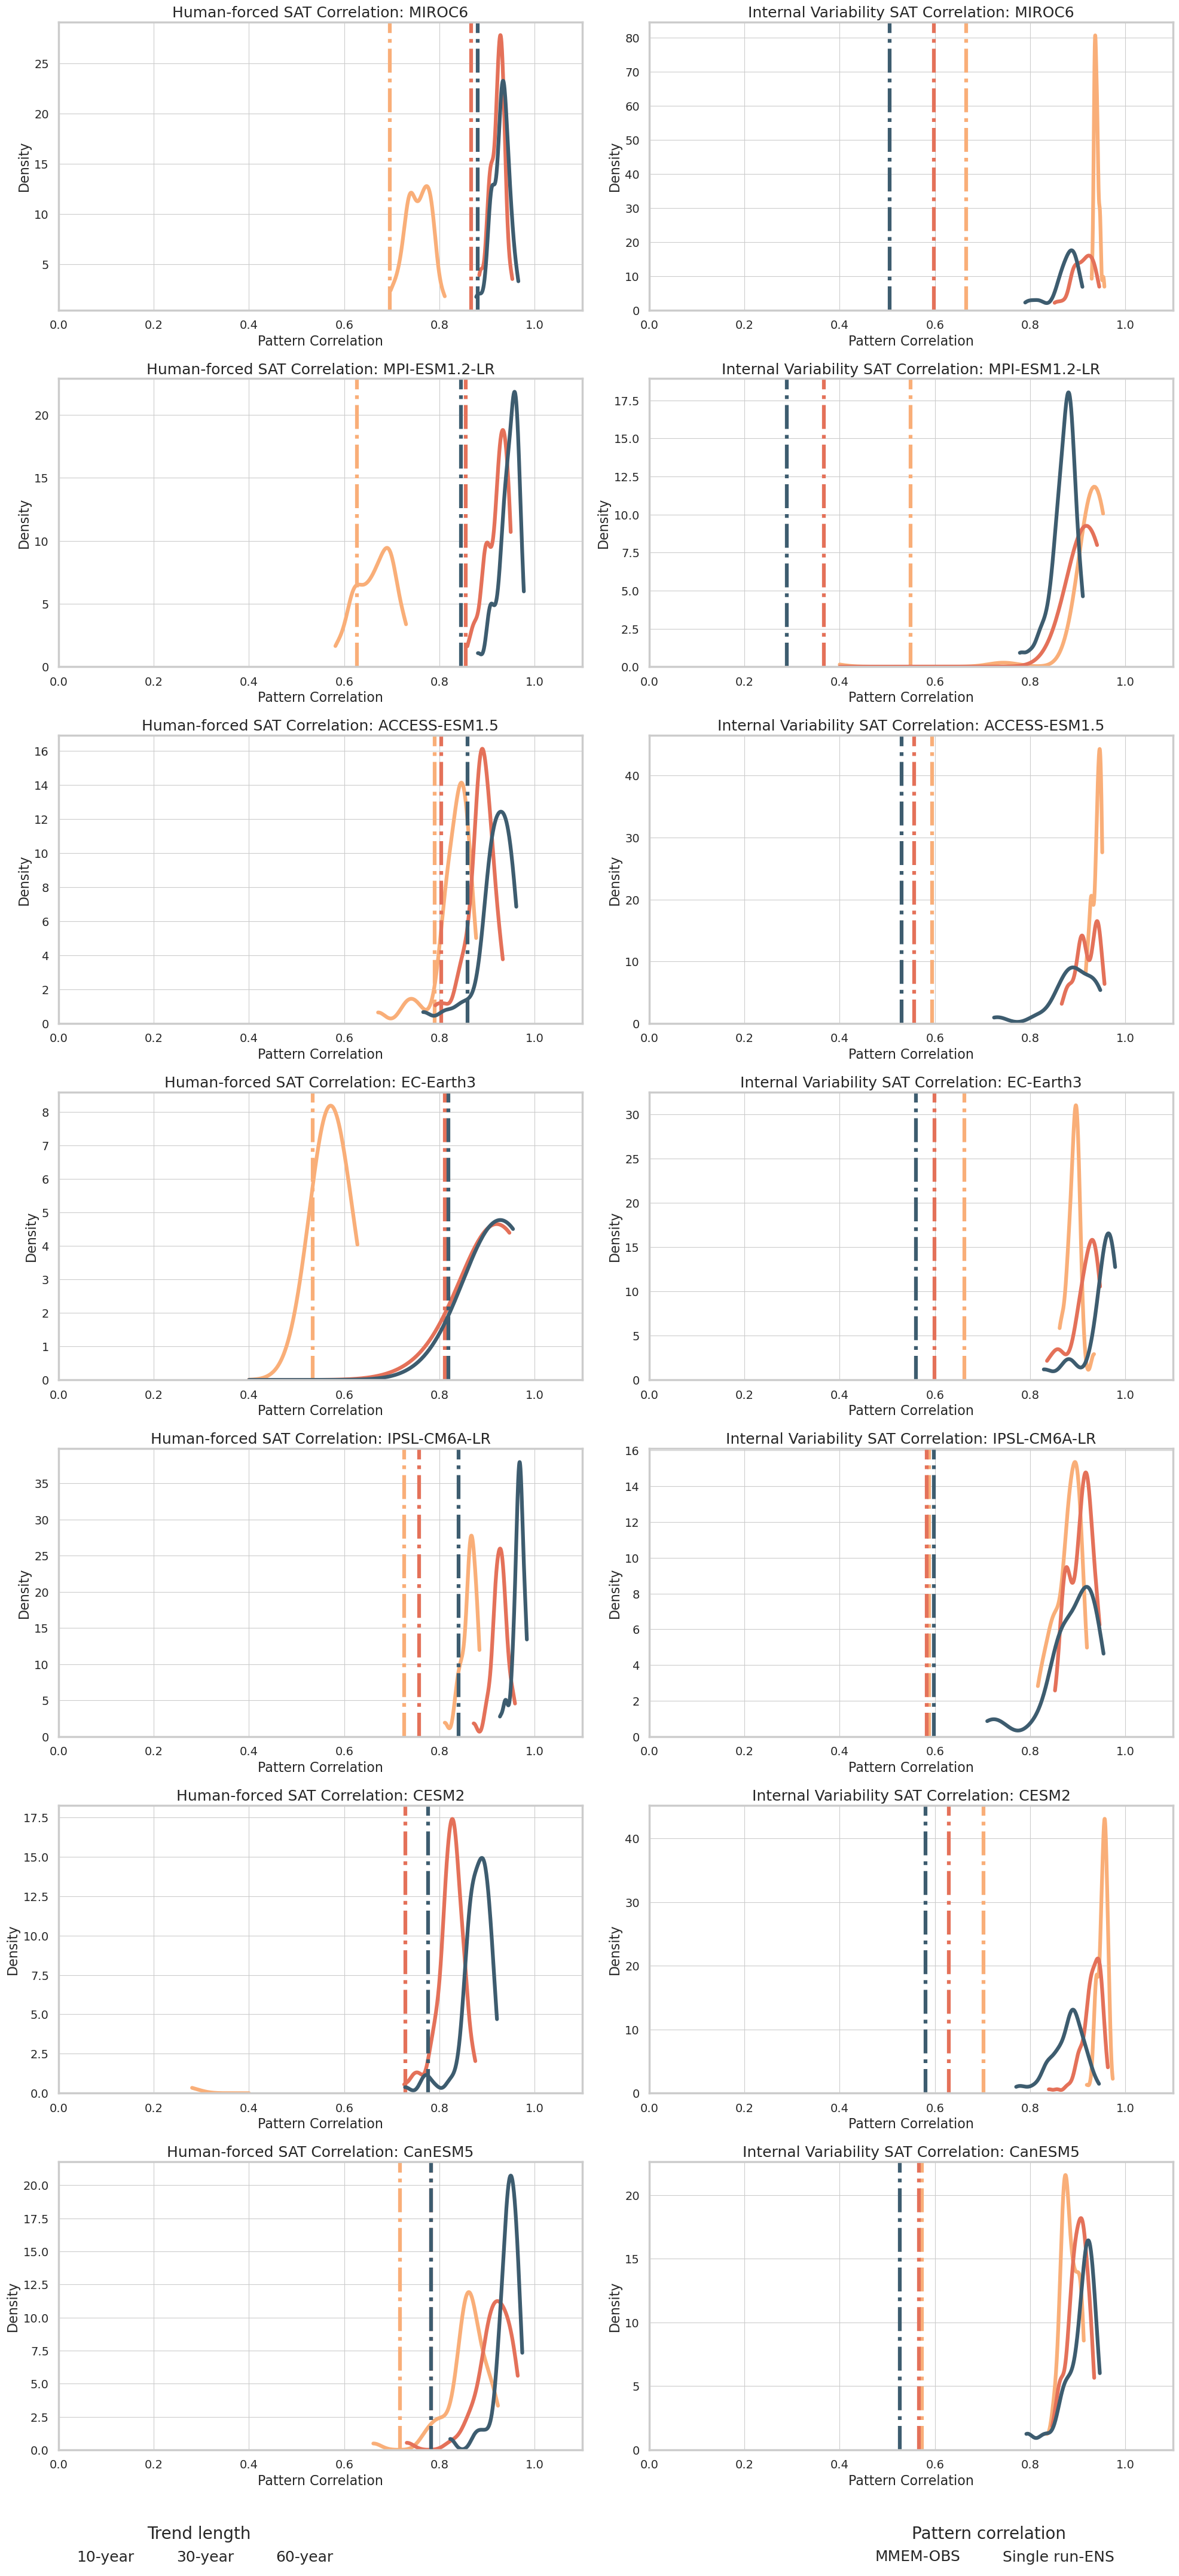

In [31]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as mticker
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Set seaborn style
sns.set_style("whitegrid")

# Color scheme and time segments
colors = ['#F9AE78', '#E47159', '#3D5C6F']
time_segments = ["10-year", "30-year", "60-year"]
models_position = ['MIROC6', 'MPI-ESM1.2-LR', 'ACCESS-ESM1.5', 'EC-Earth3', 'IPSL-CM6A-LR', 'CESM2','CanESM5']

# Create a single figure with multiple subplots
fig, axs = plt.subplots(nrows=7, ncols=2, figsize=(20, 42))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# Iterate over models and subplots
for i, model in enumerate(models_position):
    # Forced trend pattern correlation (left column)
    max_density_left = 0  # Track maximum density for left plot
    for j, segment in enumerate(time_segments):
        segment_data = models_data[model][segment]
        # Plot PDF for each model in the current time segment
        kdeplot = sns.kdeplot(segment_data, label=f"{segment}", fill=False, linewidth=4.5, 
                              color=colors[j], ax=axs[i, 0],
                              cut=0,
                              bw_adjust=0.8,
                              clip=(0.4, 1))
        # Add MMEM correlation as a vertical line
        mmem_value = ensemble_data[model][segment]
        axs[i, 0].axvline(mmem_value, color=colors[j], linestyle='-.', linewidth=4.5)
        # Update max density
        max_density_left = max(max_density_left, kdeplot.lines[0].get_ydata().max())

    axs[i, 0].set_title(f"Human-forced SAT Correlation: {model}", fontsize=18)
    axs[i, 0].set_xlim(0.0, 1.1)
    # axs[i, 0].set_ylim(0, max_density_left * 1.1)  # Add a 10% buffer
    axs[i, 0].set_xlabel("Pattern Correlation", fontsize=16)
    axs[i, 0].set_ylabel("Density", fontsize=16)
    axs[i, 0].tick_params(axis='both', which='major', labelsize=14)
    axs[i, 0].grid(True)

    # Unforced trend pattern correlation (right column)
    max_density_right = 0  # Track maximum density for right plot
    for j, segment in enumerate(time_segments):
        segment_data = models_unforced_data[model][segment]
        # Plot PDF for each model in the current time segment
        kdeplot = sns.kdeplot(segment_data, label=f"{segment}", fill=False, linewidth=4.5, 
                              color=colors[j], ax=axs[i, 1],
                              cut=0,
                              bw_adjust=0.8,
                              clip=(0.4, 1))  # Prevent cutting off the distribution tails
        # Add MMEM correlation as a vertical line
        mmem_value = ensemble_unforced_data[model][segment]
        axs[i, 1].axvline(mmem_value, color=colors[j], linestyle='-.', linewidth=4.5)
        # Update max density
        max_density_right = max(max_density_right, kdeplot.lines[0].get_ydata().max())

    axs[i, 1].set_title(f"Internal Variability SAT Correlation: {model}", fontsize=18)
    axs[i, 1].set_xlim(0.0, 1.1)
    # axs[i, 1].set_ylim(0, max_density_right * 1.1)  # Add a 10% buffer
    axs[i, 1].set_xlabel("Pattern Correlation", fontsize=16)
    axs[i, 1].set_ylabel("Density", fontsize=16)
    axs[i, 1].tick_params(axis='both', which='major', labelsize=14)
    axs[i, 1].grid(True)

# Define custom legend elements for pattern correlation and trend length
legend_elements_pattern = [
    Line2D([0], [0], color=colors[0], lw=4.5, label='10-year'),  # Solid line for 10-year
    Line2D([0], [0], color=colors[1], lw=4.5, label='30-year'),  # Solid line for 30-year
    Line2D([0], [0], color=colors[2], lw=4.5, label='60-year')   # Solid line for 60-year
]

legend_elements_time = [
    Line2D([0], [0], color='black', lw=4.5, linestyle='-.', label='MMEM-OBS'),  # Dashed line for MMEM-OBS
    Line2D([0], [0], color='black', lw=4.5, linestyle='-', label='Single run-ENS')  # Solid line for Single run-ENS
]

# Add legends to the figure
fig.legend(
    handles=legend_elements_pattern, 
    loc='lower left', 
    fontsize=18, 
    title="Trend length", 
    title_fontsize=20, 
    ncol=3, 
    bbox_to_anchor=(0.05, -0.03)
)

fig.legend(
    handles=legend_elements_time, 
    loc='lower right', 
    fontsize=18, 
    title="Pattern correlation", 
    title_fontsize=20, 
    ncol=2, 
    bbox_to_anchor=(0.95, -0.03)
)

# Adjust layout to make space for legends
plt.tight_layout(rect=[0, 0.05, 1, 1])  # Leave space at the bottom for legends

# Save the single big plot
plt.tight_layout()
plt.savefig('All_models_PDF_SAT_Pattern_Correlation.pdf', dpi=300, bbox_inches='tight')
plt.savefig('All_models_PDF_SAT_Pattern_Correlation.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# # plot the subplot b
# fig, ax = plt.subplots(figsize=(15, 8))

# for i, (model_name, model_correlations) in enumerate(models_unforced_data):
#     for j, time_period in enumerate(time_periods):
#         correlations = model_correlations[time_period]
#         y_positions = [i + (j - 1) * 0.15 for _ in correlations]  # Adjust the y-position for each time period
#         ax.scatter(correlations, y_positions, color=model_palette[model_name][j], label=f'{time_period}' if i == 0 else "", alpha=0.80, s=75)

# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# # Formatting the plot
# ax.set_yticks(models_position)
# # specify the yticks labels
# y_labels = ['CanESM5(50)', 'IPSL(32)', 'EC_Earth(21)', 'ACCESS(40)', 'MPI_ESM(50)', 'MIROC6(50)']
# ax.set_yticklabels(y_labels, fontsize=20) 
# plt.xlabel('Global SAT Trend Pattern Correlation', fontsize=22, labelpad=20)
# # ax.margins(x=0.5,y=-0.25)
# ax.set_xlim(-0.8, 0.8)
# ax.set_xticks(np.arange(-0.8, 0.8, 0.2))
# ax.set_xticklabels([f'{i:.2f}' for i in np.arange(-0.8, 0.8, 0.2)], fontsize=22)
# ax.set_ylim(-0.5, len(models_data))
# # ax.set_title('a.Single realization forced pattern vs. SMILEs ensemble pattern', 
# #              fontsize=24, fontweight='bold', loc='left', pad=20)

# # add the vertical line of the correlation value of 0.5
# ax.axvline(x=0.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
# # ax.axvline(x=0.8, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
# # Add text to the left corner of the plot
# ax.text(-1.12, 6.2, 'c', fontsize=28, fontweight='bold', ha='left', va='center')
# ax.text(-0.91, 6.2, 'Single realization unforced pattern vs. OBS'+ r'$_{wrt.SMILE} $'+ 'unforced pattern', 
#         fontsize=24, ha='left', va='center')

# # Display the plot
# fig.tight_layout()
# plt.savefig('Figure4c-pattern_correlation_single_realization_unforced_vs_obs_unforced.png', dpi=300, transparent=True)
# plt.show()
